<a href="https://colab.research.google.com/github/alicejenisha/Car-Price-prediction/blob/main/car_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 Car Price Prediction using Linear Regression

### Explainable Artificial Intelligence using LIME & SHAP

**Developed using Google Colab**

**Course:** Explainable AI

**Algorithm:** Linear Regression  

**Explainable AI:** LIME & SHAP

# 🎯 1. Aim

To develop a Machine Learning model using the **Linear Regression algorithm** to predict the price of a car based on various features such as **brand, manufacturing year, kilometers driven, fuel type, transmission, ownership, engine capacity, mileage, and number of seats**.

The project also explains the prediction results using **LIME (Local Interpretable Model-Agnostic Explanations)** and **SHAP (SHapley Additive exPlanations)**.

# 📌 2. Objectives

- Predict the **car price** using Linear Regression.
- Analyze the relationship between different car features and price.
- Preprocess categorical and numerical car-related data.
- Evaluate the performance of the Machine Learning model.
- Explain individual car price predictions using **LIME**.
- Explain global and local feature importance using **SHAP**.
- Visualize the contribution of different car features through multiple SHAP graphs.
- Improve the transparency and interpretability of the Machine Learning model.

# <font>💻 3.Software Requirements</font>

| Software | Purpose |
|-----------|----------|
| Google Colab | Development Environment |
| Python | Programming Language |
| Pandas | Data Processing |
| NumPy | Numerical Computation |
| Matplotlib | Data Visualization |
| Seaborn | Exploratory Data Visualization |
| Scikit-learn | Machine Learning |
| SHAP | Explainable AI |
| LIME | Model Interpretation |

# 📂 4. Dataset Information

**Dataset Name:** `car_price_dataset.csv`

The dataset contains **500 car records** with information about different cars.

### Input Features

| Feature | Description |
|---------|-------------|
| Brand | Brand or manufacturer of the car |
| Year | Manufacturing year of the car |
| Kilometers_Driven | Total distance driven by the car |
| Fuel_Type | Type of fuel used by the car |
| Transmission | Transmission type of the car |
| Owner | Number of previous owners |
| Engine_CC | Engine capacity in CC |
| Mileage | Fuel efficiency of the car |
| Seats | Number of seats |

### Target Variable

| Target | Description |
|--------|-------------|
| Price | Selling price of the car |

The **Price** column is the target variable that the Linear Regression model learns to predict.

# 🔄 5. Project Workflow

The Car Price Prediction system follows the workflow given below:

```text
car_price_dataset.csv
        │
        ▼
Load Dataset
        │
        ▼
Explore Dataset
        │
        ▼
Check Missing Values
        │
        ▼
Data Preprocessing
        │
        ▼
Feature Encoding
        │
        ▼
Train-Test Split
        │
        ▼
Linear Regression Model
        │
        ▼
Car Price Prediction
        │
        ▼
Model Evaluation
        │
        ▼
LIME Explanation
        │
        ▼
SHAP Analysis
        │
        ▼
New Car Price Prediction


---


```markdown
# 📚 6. Import Required Libraries

The required Python libraries are imported for data processing, visualization, Machine Learning, and Explainable AI.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 📥 7. Load the Dataset

The `car_price_dataset.csv` file is loaded into a Pandas DataFrame for further analysis and Machine Learning.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving car_price_dataset.csv to car_price_dataset.csv


# 👀 8. Display the Dataset

The first five records of the dataset are displayed to understand its structure and the available features.

In [ ]:
df = pd.read_csv("car_price_dataset.csv")

df.head()

,Brand,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner,Engine_CC,Mileage,Seats,Price
0,Hyundai,2014,102196,Diesel,Manual,1,1197,20.8,5,282000
1,Ford,2014,8905,Petrol,Manual,1,998,19.3,7,278000
2,Volkswagen,2023,41463,Petrol,Manual,1,1497,15.6,5,965000
3,Hyundai,2015,54797,Petrol,Automatic,2,1396,22.5,7,462000
4,Hyundai,2020,15328,CNG,Automatic,2,1497,19.5,5,748000


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (500, 10)

Columns:
Index(['Brand', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission',
       'Owner', 'Engine_CC', 'Mileage', 'Seats', 'Price'],
      dtype='object')

Missing Values:
Brand                0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner                0
Engine_CC            0
Mileage              0
Seats                0
Price                0
dtype: int64


In [ ]:
df = df.drop(columns=["Car_ID"], errors="ignore")

In [ ]:
df = df.drop_duplicates()

In [ ]:
df = df.dropna()

# 📊 9. Dataset Information

The `info()` function is used to display the number of records, columns, data types, and memory usage of the dataset.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand              500 non-null    object 
 1   Year               500 non-null    int64  
 2   Kilometers_Driven  500 non-null    int64  
 3   Fuel_Type          500 non-null    object 
 4   Transmission       500 non-null    object 
 5   Owner              500 non-null    int64  
 6   Engine_CC          500 non-null    int64  
 7   Mileage            500 non-null    float64
 8   Seats              500 non-null    int64  
 9   Price              500 non-null    int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 39.2+ KB


# 📊 10. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the distribution of car prices and the relationship between important car features and the target variable.

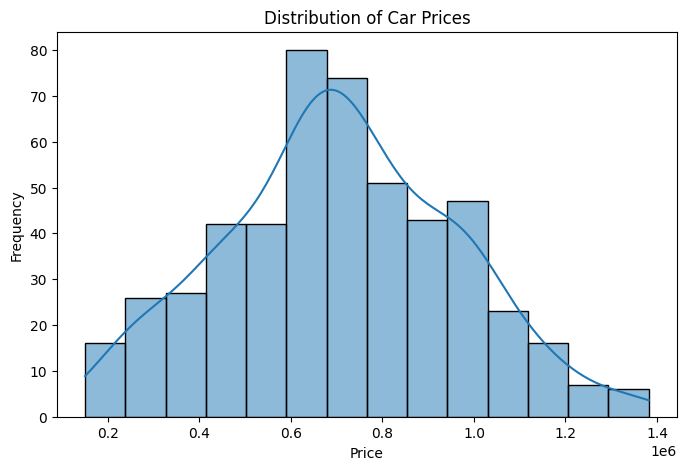

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

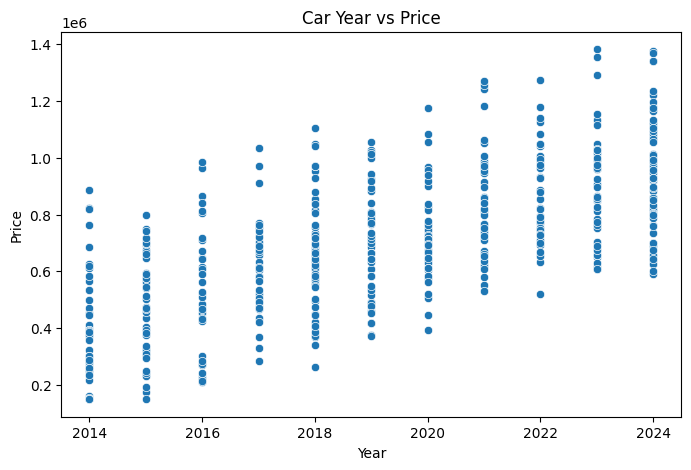

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Year", y="Price")
plt.title("Car Year vs Price")
plt.show()

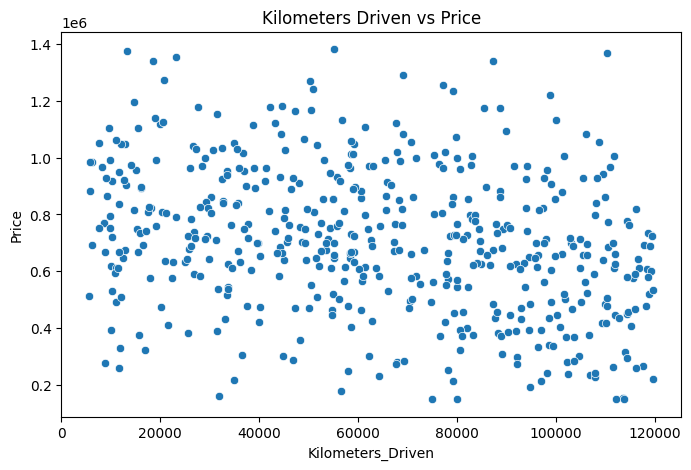

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Kilometers_Driven", y="Price")
plt.title("Kilometers Driven vs Price")
plt.show()

# 🎯 11. Define Features and Target Variable

The dataset is divided into input features **X** and the target variable **y**.

### Input Features

Brand, Year, Kilometers_Driven, Fuel_Type, Transmission, Owner, Engine_CC, Mileage, and Seats.

### Target Variable

Price.

In [ ]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [ ]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Brand', 'Fuel_Type', 'Transmission']

Numerical Features:
['Year', 'Kilometers_Driven', 'Owner', 'Engine_CC', 'Mileage', 'Seats']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

# ✂️ 12. Train-Test Split

The dataset is divided into training and testing sets.

- **80% of the data** is used for training.
- **20% of the data** is used for testing.

The training data is used to build the model, while the testing data is used to evaluate its performance.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 9)
Testing data: (100, 9)


In [ ]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Brand', 'Fuel_Type',
                                                   'Transmission'])])),
                ('regressor', LinearRegression())])

In [ ]:
y_pred = model.predict(X_test)

print("Predicted Prices:")
print(y_pred[:10])

Predicted Prices:
[ 458616.88053507  471247.08341584  604358.30958296  780422.37069182
  754974.51927491  708505.0083252   747206.58486612  388439.73141387
  739350.34099703 1122504.87909271]


# 📊 13. Model Evaluation

The performance of the Linear Regression model is evaluated using the following metrics:

- **Mean Absolute Error (MAE)**
- **Mean Squared Error (MSE)**
- **Root Mean Squared Error (RMSE)**
- **R² Score**

These metrics help determine how accurately the model predicts car prices.

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 27327.128035558166
Root Mean Squared Error: 30457.782269674568
R2 Score: 0.9846011634450708


# 📈 14. Actual vs Predicted Car Prices

The actual car prices are compared with the prices predicted by the Linear Regression model.

A scatter plot is used to visualize how closely the predicted prices follow the actual prices.

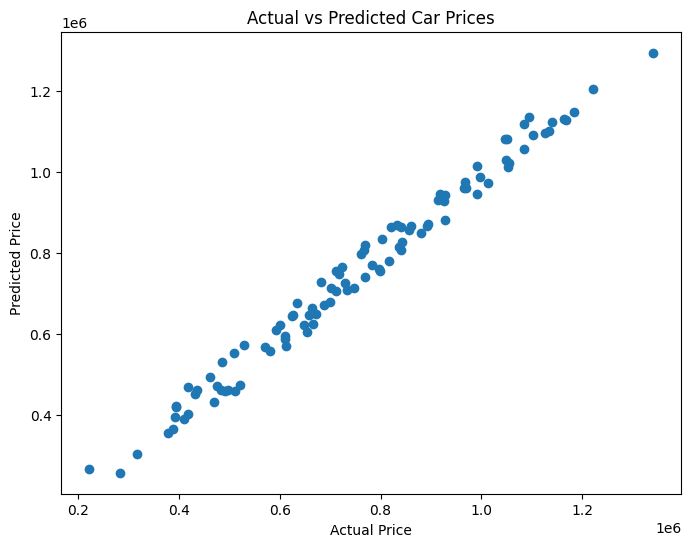

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [ ]:
new_car = pd.DataFrame({
    "Brand": ["Hyundai"],
    "Year": [2021],
    "Kilometers_Driven": [25000],
    "Fuel_Type": ["Petrol"],
    "Transmission": ["Automatic"],
    "Owner": [1],
    "Engine_CC": [1497],
    "Mileage": [18.5],
    "Seats": [5]
})

In [ ]:
predicted_price = model.predict(new_car)

print("Predicted Car Price:", predicted_price[0])

Predicted Car Price: 853906.5087866187


In [ ]:
print(f"Predicted Car Price: ₹{predicted_price[0]:,.2f}")

Predicted Car Price: ₹853,906.51


# 🎯 15. LIME Explanation for an Individual Car Prediction

LIME is used to explain the prediction of an individual car.

The explanation shows which features contributed positively or negatively to the predicted car price.

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c116960d1f768255c09a1cf277acbc15887f6ea089f5b10c801eab04666dcf09
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import lime
import lime.lime_tabular

In [ ]:
predict_fn = lambda x: model.predict(
    pd.DataFrame(x, columns=X.columns)
)

In [ ]:
# Get the preprocessing and Linear Regression model
preprocessor = model.named_steps["preprocessor"]
linear_model = model.named_steps["regressor"]

# Transform the training data
X_train_transformed = preprocessor.transform(X_train)

# Convert sparse matrix to normal NumPy array
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

print("LIME data prepared successfully!")
print("Number of features:", len(feature_names))

LIME data prepared successfully!
Number of features: 21


In [ ]:
!pip install -q lime

import lime
import lime.lime_tabular

In [ ]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_transformed,
    feature_names=feature_names.tolist(),
    mode="regression",
    random_state=42
)

print("LIME explainer created successfully!")

LIME explainer created successfully!


In [ ]:
predict_fn = lambda x: linear_model.predict(x)

In [ ]:
instance = X_train_transformed[0]

lime_exp = explainer.explain_instance(
    instance,
    predict_fn,
    num_features=10
)

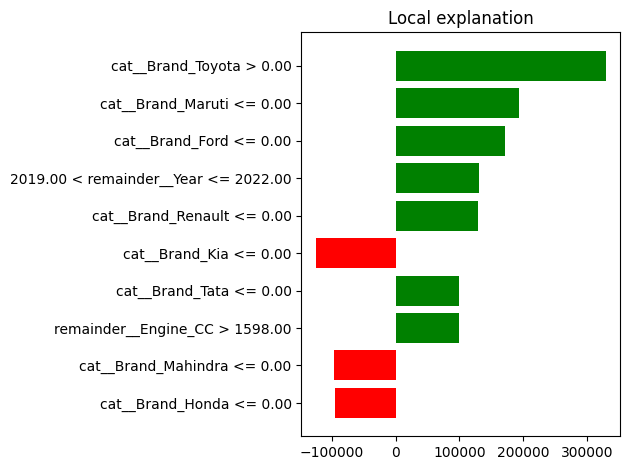

In [ ]:
import matplotlib.pyplot as plt

lime_exp.as_pyplot_figure()

plt.tight_layout()
plt.show()

In [ ]:
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.2f}")

cat__Brand_Toyota > 0.00: 329154.87
cat__Brand_Maruti <= 0.00: 193579.05
cat__Brand_Ford <= 0.00: 170788.16
2019.00 < remainder__Year <= 2022.00: 131341.17
cat__Brand_Renault <= 0.00: 128761.91
cat__Brand_Kia <= 0.00: -125469.69
cat__Brand_Tata <= 0.00: 99949.82
remainder__Engine_CC > 1598.00: 98776.21
cat__Brand_Mahindra <= 0.00: -97406.23
cat__Brand_Honda <= 0.00: -95868.33


In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Brand', 'Fuel_Type',
                                                   'Transmission'])])),
                ('regressor', LinearRegression())])

In [ ]:
!pip install -q shap

In [ ]:
import shap
import matplotlib.pyplot as plt

# ⚙️ 16. Create SHAP Explainer

In [ ]:
# Transform test data using the same preprocessor
X_test_transformed = preprocessor.transform(X_test)

# Convert sparse matrix to dense array
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

print("Test data prepared for SHAP!")
print("Shape:", X_test_transformed.shape)

Test data prepared for SHAP!
Shape: (100, 21)


In [ ]:
shap_explainer = shap.LinearExplainer(
    linear_model,
    X_train_transformed
)

print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [ ]:
shap_values = shap_explainer(X_test_transformed)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


# 📊 17. SHAP Summary Plot

The SHAP Summary Plot provides an overall view of how different car features influence the predicted prices.

Features with larger SHAP values have a greater impact on the model's predictions.

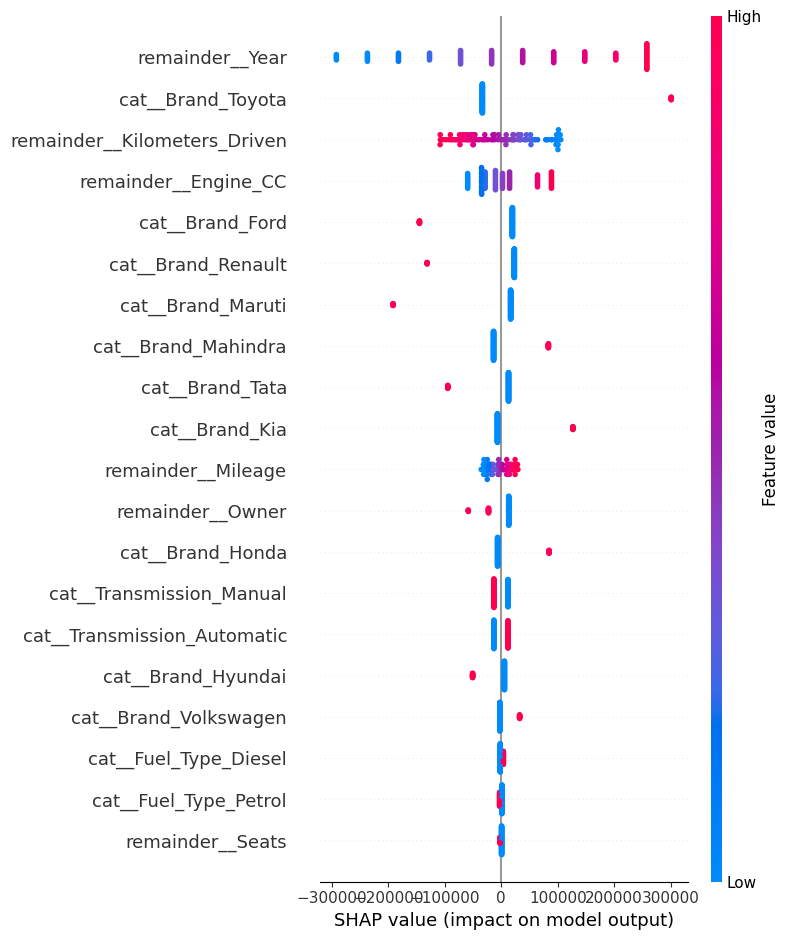

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

# 📊 18. SHAP Feature Importance Bar Plot

The SHAP Bar Plot displays the average importance of each feature.

It helps identify the car features that have the greatest overall influence on price prediction.

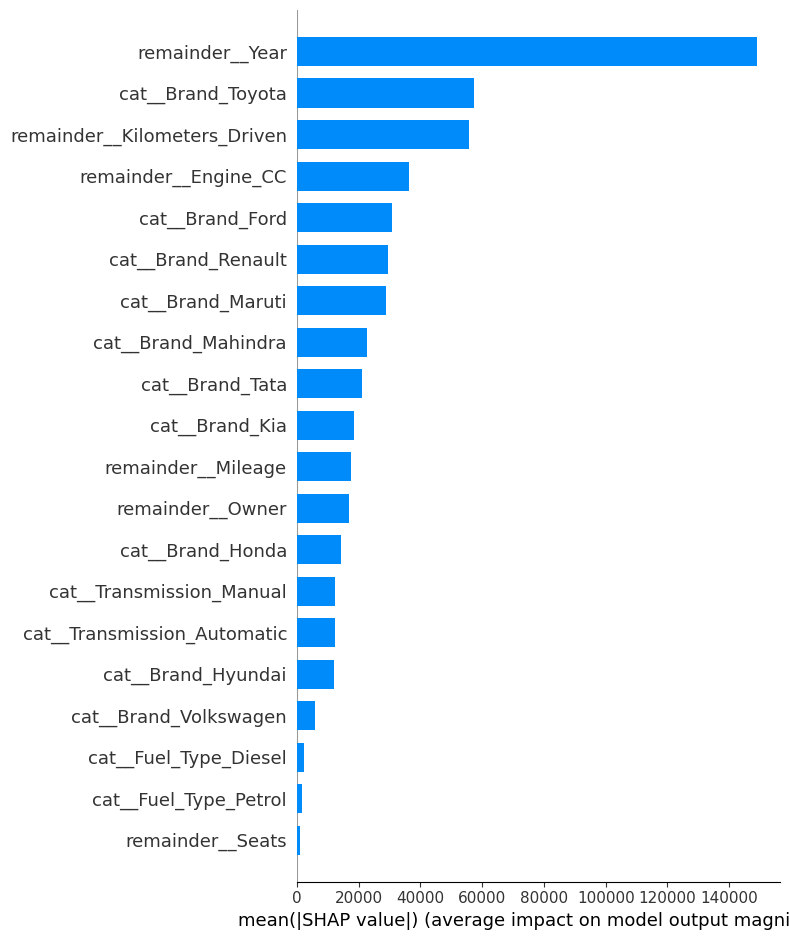

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

# 🌊 19. SHAP Waterfall Plot

The SHAP Waterfall Plot explains the contribution of individual features to a single car-price prediction.

It shows how each feature moves the prediction away from the model's average prediction.

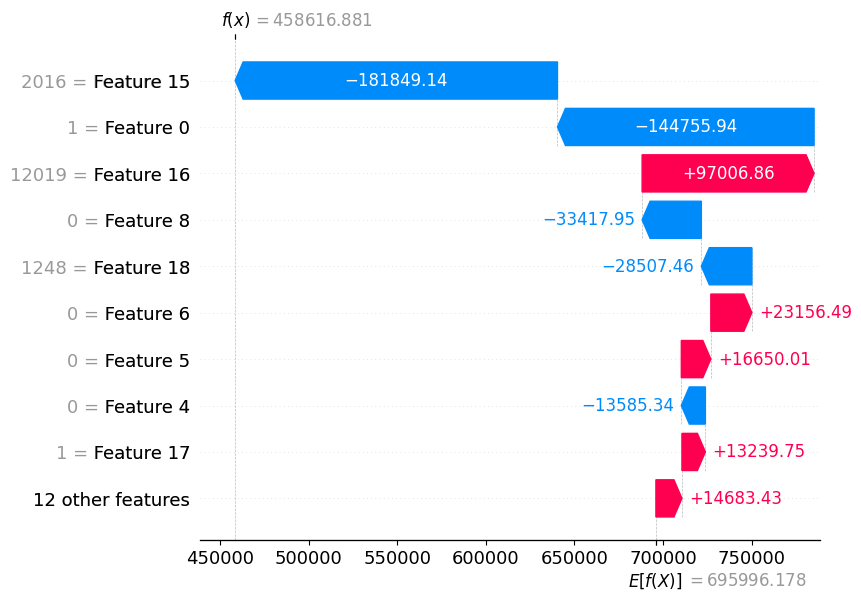

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict test data
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-------------------------")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

Model Evaluation
-------------------------
MAE  : 27327.128035558166
RMSE : 30457.782269674568
R²   : 0.9846011634450708


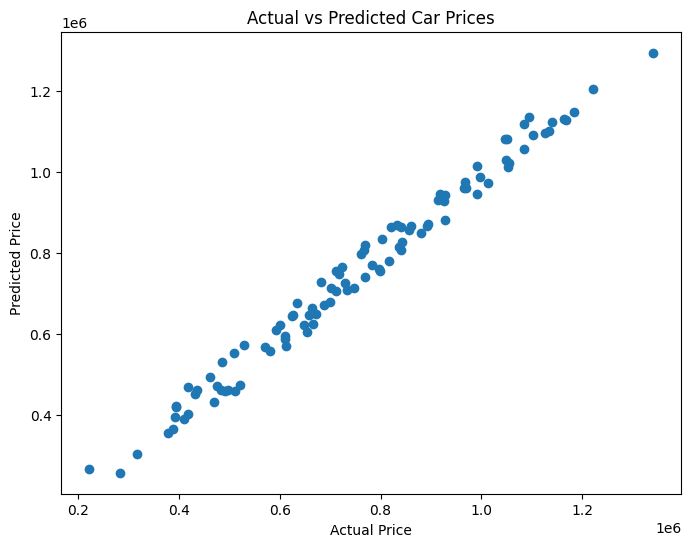

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [ ]:
new_car = pd.DataFrame({
    "Brand": ["Hyundai"],
    "Year": [2021],
    "Kilometers_Driven": [25000],
    "Fuel_Type": ["Petrol"],
    "Transmission": ["Automatic"],
    "Owner": [1],
    "Engine_CC": [1497],
    "Mileage": [18.5],
    "Seats": [5]
})

predicted_price = model.predict(new_car)

print("Predicted Car Price: ₹{:,.2f}".format(predicted_price[0]))

Predicted Car Price: ₹853,906.51


In [ ]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,510000,4.586169e+05
1,476000,4.712471e+05
2,653000,6.043583e+05
3,816000,7.804224e+05
4,798000,7.549745e+05
5,734000,7.085050e+05
6,718000,7.472066e+05
7,410000,3.884397e+05
8,770000,7.393503e+05
9,1140000,1.122505e+06


In [ ]:
# Transform one test car
test_instance = preprocessor.transform(X_test.iloc[[0]])

if hasattr(test_instance, "toarray"):
    test_instance = test_instance.toarray()

test_instance = test_instance[0]

# Generate LIME explanation
lime_exp = explainer.explain_instance(
    test_instance,
    predict_fn,
    num_features=10
)

# Display explanation
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.2f}")

cat__Brand_Toyota <= 0.00: -327592.54
remainder__Year <= 2016.00: -308133.19
cat__Brand_Maruti <= 0.00: 212110.47
cat__Brand_Ford > 0.00: -172927.99
cat__Brand_Renault <= 0.00: 155945.50
cat__Brand_Kia <= 0.00: -132620.22
remainder__Kilometers_Driven <= 35791.50: 110006.85
cat__Brand_Tata <= 0.00: 94419.86
cat__Brand_Mahindra <= 0.00: -93359.51
remainder__Owner <= 1.00: 81740.79


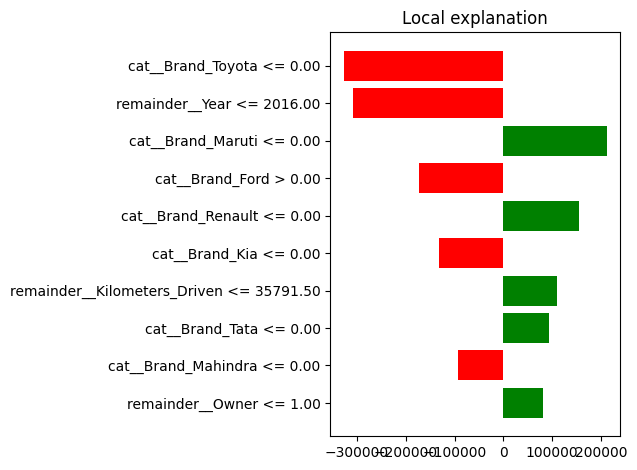

In [ ]:
lime_exp.as_pyplot_figure()

plt.tight_layout()
plt.show()

# 📋 20. Results and Discussion

The Linear Regression model was trained successfully to predict car prices using different vehicle characteristics.

The model performance was evaluated using **MAE, MSE, RMSE, and R² Score**.

The **Actual vs Predicted** graph was used to compare the model's predictions with the actual car prices.

**LIME** provided local explanations for individual car-price predictions, while **SHAP** provided both global and local explanations of the model.

The SHAP Summary, Bar, Beeswarm, Waterfall, and Heatmap visualizations helped identify the contribution and importance of different car features.

# 🎉 21. Conclusion

The **Car Price Prediction system** was successfully developed using the **Linear Regression algorithm**. The model uses important vehicle characteristics such as **Brand, Year, Kilometers Driven, Fuel Type, Transmission, Owner, Engine Capacity, Mileage, and Seats** to predict car prices.

The model was evaluated using **MAE, MSE, RMSE, and R² Score** to measure its prediction performance.

To improve model transparency, **LIME** was used to explain individual car-price predictions, while **SHAP** was used to understand both global and local feature contributions.

The project demonstrates how **Explainable Artificial Intelligence (XAI)** can make Machine Learning predictions more transparent, interpretable, and understandable.

# 🏆 22. Project Outcomes

- Successfully loaded and analyzed the car price dataset.
- Preprocessed numerical and categorical features.
- Developed a Linear Regression model for car price prediction.
- Evaluated the model using multiple performance metrics.
- Visualized actual and predicted car prices.
- Implemented LIME for local model interpretation.
- Implemented SHAP for global and local model interpretation.
- Generated multiple SHAP visualizations.
- Predicted the price of a new car.
- Improved the transparency and interpretability of the Machine Learning model.

# 🚗 23. Real-World Applications

- Used-Car Price Estimation
- Automobile Resale Price Prediction
- Car Dealership Pricing Systems
- Online Car Marketplace Applications
- Vehicle Valuation Systems
- Automobile Market Analysis
- Buyer and Seller Decision Support
- Vehicle Loan and Financing Support

# 🚀 24. Future Enhancements

- Use a larger real-world car price dataset.
- Add additional features such as location, service history, accident history, and insurance status.
- Compare Linear Regression with advanced algorithms such as Random Forest, XGBoost, and Gradient Boosting.
- Deploy the prediction model as a web application using Flask or Streamlit.
- Develop a mobile application for car price prediction.
- Integrate real-time automobile marketplace data.
- Improve model accuracy using hyperparameter optimization.
- Add interactive LIME and SHAP visualizations.

# 💻 25. Technologies Used

| Technology | Purpose |
|------------|---------|
| Python | Programming Language |
| Google Colab | Development Environment |
| Pandas | Data Processing |
| NumPy | Numerical Computation |
| Matplotlib | Data Visualization |
| Seaborn | Exploratory Data Visualization |
| Scikit-learn | Machine Learning |
| LIME | Local Model Interpretation |
| SHAP | Explainable Artificial Intelligence |

# 🏁 26. Final Result

The **Car Price Prediction system** successfully predicts car prices using the **Linear Regression algorithm** based on various vehicle characteristics.

The integration of **LIME and SHAP** provides interpretable explanations of the model's predictions. LIME explains individual predictions, while SHAP provides both global and local feature importance.

Therefore, the developed system provides a **transparent, interpretable, and explainable Machine Learning approach for car price prediction**.

Google colab link:https://colab.research.google.com/drive/1anr1XTB_eruDNT6of5qy8t8cSb1oh7yI?usp=sharing